# 📊 Data Profiling — Dislog PFE

**Objective**: Explore all raw CSV files to understand data quality, distributions, missing values, and relationships before building the ETL pipeline.

---

## Table of Contents

1. [Setup & Configuration](#1)
2. [File Overview](#2)
3. [Dimension Tables](#3)
   - 3.1 Region
   - 3.2 Sector
   - 3.3 Customer
   - 3.4 Seller
   - 3.5 Product
4. [Fact Tables](#4)
   - 4.1 SalesHeader
   - 4.2 SalesLine
   - 4.3 Invoice
5. [Missing Values Summary](#5)
6. [Referential Integrity](#6)
7. [Key Findings & Next Steps](#7)

<a id='1'></a>
## 1. Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, HTML

# ── Style ──
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# ── Paths ──
DATA_DIR = Path(__file__).resolve().parent.parent / 'Data' if '__file__' in globals() else Path('C:/Users/21261/Desktop/dislog-pfe/Data')
SEP = ';'  # All CSVs use semicolon delimiter

print('✅ Setup complete!')
print(DATA_DIR)


✅ Setup complete!
C:\Users\21261\Desktop\dislog-pfe\Data


<a id='2'></a>
## 2. File Overview

Let's first see what we're working with:

In [2]:
# ── File sizes ──
csv_files = {
    'Region':       {'file': 'Region.csv',       'encoding': 'utf-8',  'type': 'Dimension'},
    'Sector':       {'file': 'Sector.csv',       'encoding': 'cp1252', 'type': 'Dimension'},
    'Customer':     {'file': 'Customer.csv',     'encoding': 'utf-8',  'type': 'Dimension'},
    'Seller':       {'file': 'Seller.csv',       'encoding': 'utf-8',  'type': 'Dimension'},
    'Product':      {'file': 'Products.csv',     'encoding': 'utf-8',  'type': 'Dimension'},
    'SalesHeader':  {'file': 'SalesHeader.csv',  'encoding': 'utf-8',  'type': 'Fact'},
    'SalesLine':    {'file': 'SalesLine.csv',    'encoding': 'cp1252', 'type': 'Fact'},
    'Invoice':      {'file': 'Invoice.csv',      'encoding': 'cp1252', 'type': 'Fact'},
}

overview = []
for name, info in csv_files.items():
    fpath = DATA_DIR / info['file']
    size_mb = fpath.stat().st_size / (1024 * 1024)
    overview.append({
        'Table': name,
        'File': info['file'],
        'Size (MB)': round(size_mb, 2),
        'Encoding': info['encoding'],
        'Type': info['type']
    })

overview_df = pd.DataFrame(overview)
overview_df.style.background_gradient(subset=['Size (MB)'], cmap='YlOrRd')

# ─────────────────────────────────────────────────────────────────────────────
#  Shared styling helpers
# ─────────────────────────────────────────────────────────────────────────────
_BLUE   = "#2E75B6"
_STRIPE = "#f2f7fc"

def _styled_table(df_input):
    rows = "<thead><tr style=\'background:#2E75B6; color:white;\'>"
    rows += "<th style=\'padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\'>#</th>"
    for col in df_input.columns:
        rows += f"<th style=\'padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\'>{col}</th>"
    rows += "</tr></thead><tbody>"
    for i, (_, row) in enumerate(df_input.iterrows()):
        bg = "white" if i % 2 == 0 else _STRIPE
        rows += f"<tr style=\'background:{bg};\'>"
        rows += f"<td style=\'padding:6px 14px; font-size:13px; color:#888; border-bottom:1px solid #dde4ed;\'>{i}</td>"
        for val in row:
            rows += f"<td style=\'padding:6px 14px; font-size:13px; color:#1a1a1a; border-bottom:1px solid #dde4ed;\'>{val}</td>"
        rows += "</tr>"
    rows += "</tbody>"
    return f"<table style=\'border-collapse:collapse; width:100%; margin-bottom:20px;\'>{rows}</table>"

def _section_label(text):
    return (
        f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; font-size:11px; font-weight:700; "
        f"color:{_BLUE}; letter-spacing:0.7px; text-transform:uppercase; margin-bottom:7px;\">{text}</div>"
    )

def _title_banner(name, nrows, ncols):
    return (
        f"<div style=\"background:{_BLUE}; padding:10px 16px; margin-bottom:18px;\">"
        f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; font-size:17px; font-weight:700; color:#ffffff;\">{name}</div>"
        f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; font-size:12px; color:#cce3f5; margin-top:3px;\">"
        f"{nrows:,} rows &nbsp;·&nbsp; {ncols} columns</div></div>"
    )

def _col_overview(df, nulls, null_pct):
    html = _section_label("Column Overview")
    html += (
        f"<table style=\"border-collapse:collapse; width:100%; margin-bottom:20px;\">"
        f"<thead><tr style=\"background:{_BLUE}; color:white;\">"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Column</th>"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Type</th>"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Nulls</th>"
        f"<th style=\"padding:7px 14px; font-size:13px; font-weight:600; text-align:left;\">Null %</th>"
        f"</tr></thead><tbody>"
    )
    for i, col in enumerate(df.columns):
        bg = "white" if i % 2 == 0 else _STRIPE
        nc = "#C00000" if nulls[col] > 0 else "#375623"
        html += (
            f"<tr style=\"background:{bg};\">"
            f"<td style=\"padding:6px 14px; font-size:13px; color:#1a1a1a; border-bottom:1px solid #dde4ed;\">{col}</td>"
            f"<td style=\"padding:6px 14px; font-size:13px; color:#555; border-bottom:1px solid #dde4ed;\">{df[col].dtype}</td>"
            f"<td style=\"padding:6px 14px; font-size:13px; color:{nc}; border-bottom:1px solid #dde4ed;\">{nulls[col]:,}</td>"
            f"<td style=\"padding:6px 14px; font-size:13px; color:{nc}; border-bottom:1px solid #dde4ed;\">{null_pct[col]}%</td>"
            f"</tr>"
        )
    html += "</tbody></table>"
    return html

def profile_dataframe(name, df):
    nulls    = df.isnull().sum()
    null_pct = (nulls / len(df) * 100).round(1)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    html  = f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; margin:32px 0 24px 0; max-width:1100px;\">"
    html += _title_banner(name, df.shape[0], df.shape[1])
    html += _col_overview(df, nulls, null_pct)
    html += _section_label("Sample Rows (first 5)")
    html += _styled_table(df.head())
    if num_cols:
        html += _section_label("Numeric Summary")
        html += _styled_table(df[num_cols].describe().round(2).reset_index().rename(columns={"index": "stat"}))
    html += "</div><hr style=\'border:none; border-top:1px solid #dde4ed; margin:4px 0 0 0;\'>"
    display(HTML(html))

def profile_fact_table(name, df, distinct_checks: dict):
    nulls    = df.isnull().sum()
    null_pct = (nulls / len(df) * 100).round(1)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    html  = f"<div style=\"font-family:Calibri,\'Segoe UI\',sans-serif; margin:32px 0 24px 0; max-width:1100px;\">"
    html += _title_banner(name, df.shape[0], df.shape[1])
    if distinct_checks:
        html += _section_label("Key Metrics")
        html += "<div style=\"display:flex; gap:16px; margin-bottom:20px; flex-wrap:wrap;\">"
        for col, label in distinct_checks.items():
            count = df[col].nunique()
            html += (
                f"<div style=\"background:{_STRIPE}; border:1px solid #dde4ed; border-top:3px solid {_BLUE}; "
                f"padding:12px 20px; min-width:160px;\">"
                f"<div style=\"font-size:11px; color:#888; text-transform:uppercase; letter-spacing:0.5px; margin-bottom:4px;\">{label}</div>"
                f"<div style=\"font-size:22px; font-weight:700; color:#1a1a1a;\">{count:,}</div>"
                f"</div>"
            )
        html += "</div>"
    html += _col_overview(df, nulls, null_pct)
    html += _section_label("Sample Rows (first 5)")
    html += _styled_table(df.head())
    if num_cols:
        html += _section_label("Numeric Summary")
        html += _styled_table(df[num_cols].describe().round(2).reset_index().rename(columns={"index": "stat"}))
    html += "</div><hr style=\'border:none; border-top:1px solid #dde4ed; margin:4px 0 0 0;\'>"
    display(HTML(html))
    overview_df = pd.DataFrame(overview)
    
display(overview_df.style.background_gradient(subset=['Size (MB)'], cmap='YlOrRd'))
    

,Table,File,Size (MB),Encoding,Type
0,Region,Region.csv,0.000000,utf-8,Dimension
1,Sector,Sector.csv,0.010000,cp1252,Dimension
2,Customer,Customer.csv,3.850000,utf-8,Dimension
3,Seller,Seller.csv,0.010000,utf-8,Dimension
4,Product,Products.csv,0.140000,utf-8,Dimension
5,SalesHeader,SalesHeader.csv,117.590000,utf-8,Fact
6,SalesLine,SalesLine.csv,686.100000,cp1252,Fact
7,Invoice,Invoice.csv,62.650000,cp1252,Fact


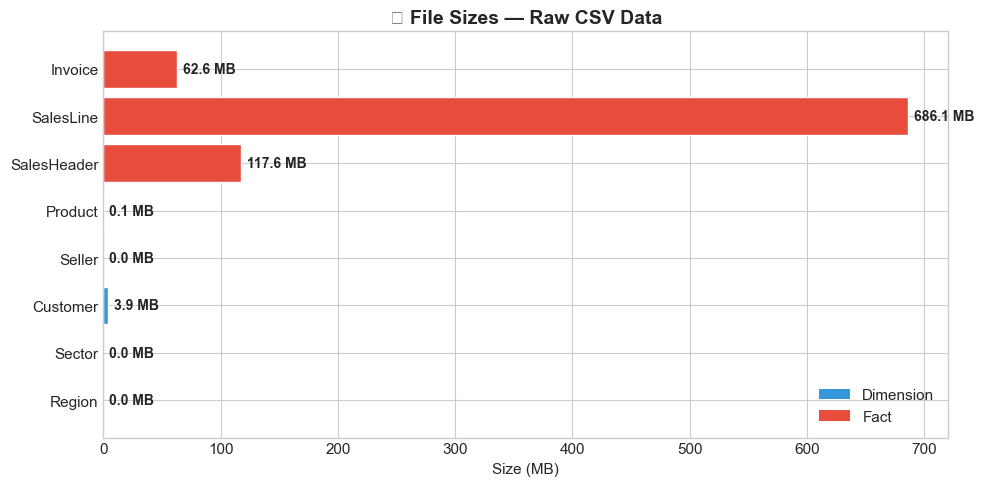

In [3]:
# ── Visual: File sizes ──
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db' if t == 'Dimension' else '#e74c3c' for t in overview_df['Type']]
bars = ax.barh(overview_df['Table'], overview_df['Size (MB)'], color=colors, edgecolor='white')
ax.set_xlabel('Size (MB)')
ax.set_title('📁 File Sizes — Raw CSV Data')

# Add size labels
for bar, size in zip(bars, overview_df['Size (MB)']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{size:.1f} MB', va='center', fontweight='bold', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Dimension'), 
                   Patch(facecolor='#e74c3c', label='Fact')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

<a id='3'></a>
## 3. Dimension Tables

---

### 3.1 Region

In [4]:
region = pd.read_csv(DATA_DIR / 'Region.csv', sep=SEP, encoding='utf-8')
profile_dataframe('Region', region)


### 3.2 Sector

In [5]:
sector = pd.read_csv(DATA_DIR / 'Sector.csv', sep=SEP, encoding='cp1252')
profile_dataframe('Sector', sector)


### 3.3 Customer

In [6]:
customer = pd.read_csv(DATA_DIR / 'Customer.csv', sep=SEP, encoding='utf-8')
profile_dataframe('Customer', customer)


In [7]:
# Missing values detail for Customer
missing_customer = customer.isnull().sum()
missing_pct      = (customer.isnull().sum() / len(customer) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_customer, 'Missing %': missing_pct}).reset_index().rename(columns={'index': 'Column'})
profile_dataframe('Customer — Missing Values', missing_df)


Column,Type,Nulls,Null %
Column,str,0,0.0%
Missing Count,int64,0,0.0%
Missing %,float64,0,0.0%
#,Column,Missing Count,Missing %
0,accountid,0,0.0
1,accountname,10341,11.8
2,regionid,192,0.22
3,sectorid,317,0.36
#,stat,Missing Count,Missing %
0,count,4.0,4.0


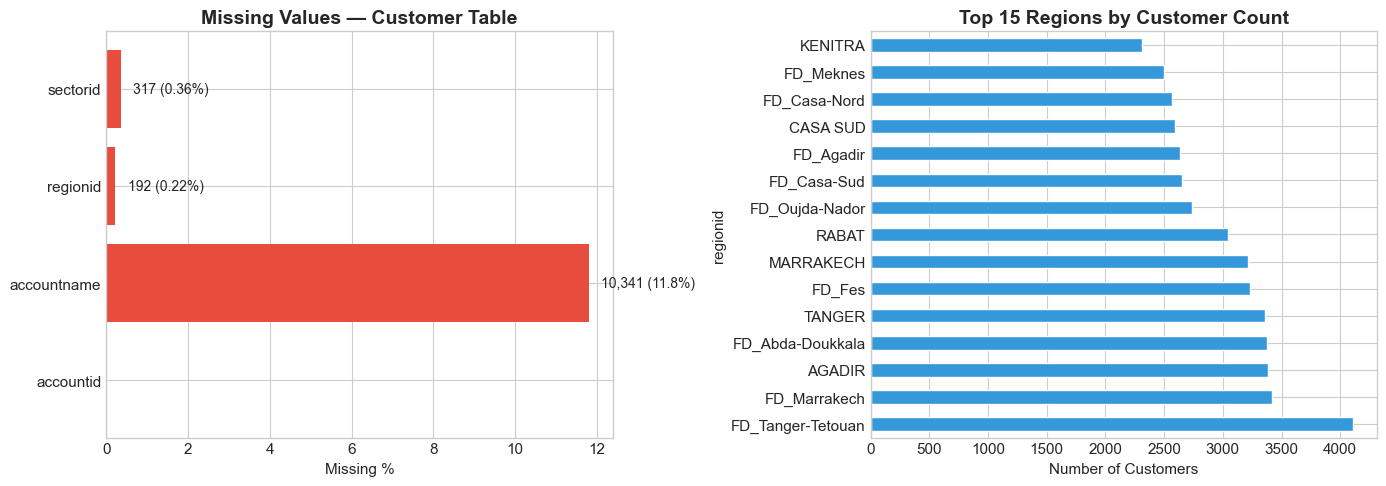

In [8]:
# ── Visual: Missing values heatmap for Customer ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of missing values
colors_missing = ['#e74c3c' if v > 0 else '#2ecc71' for v in missing_customer]
axes[0].barh(missing_customer.index, missing_pct, color=colors_missing)
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values — Customer Table')
for i, (val, pct) in enumerate(zip(missing_customer, missing_pct)):
    if val > 0:
        axes[0].text(pct + 0.3, i, f'{val:,} ({pct}%)', va='center', fontsize=10)

# Customers per region (top 15)
region_counts = customer['regionid'].value_counts().head(15)
region_counts.plot.barh(ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Top 15 Regions by Customer Count')
axes[1].set_xlabel('Number of Customers')

plt.tight_layout()
plt.show()

In [9]:
# Duplicates in Customer
dup_count = customer.duplicated().sum()
dup_ids   = customer[customer['accountid'].duplicated(keep=False)]

if dup_count > 0:
    profile_dataframe(f'Duplicate Rows in Customer ({dup_count} rows)',
                      customer[customer.duplicated(keep=False)].sort_values('accountid').head(20).reset_index(drop=True))
else:
    display(HTML("<div style='font-family:Calibri,\'Segoe UI\',sans-serif; color:#375623; font-weight:700;'>✅ No duplicate rows in Customer.</div>"))

if len(dup_ids) > 0:
    profile_dataframe(f'Duplicate accountid values ({len(dup_ids)} rows)',
                      dup_ids.sort_values('accountid').head(20).reset_index(drop=True))


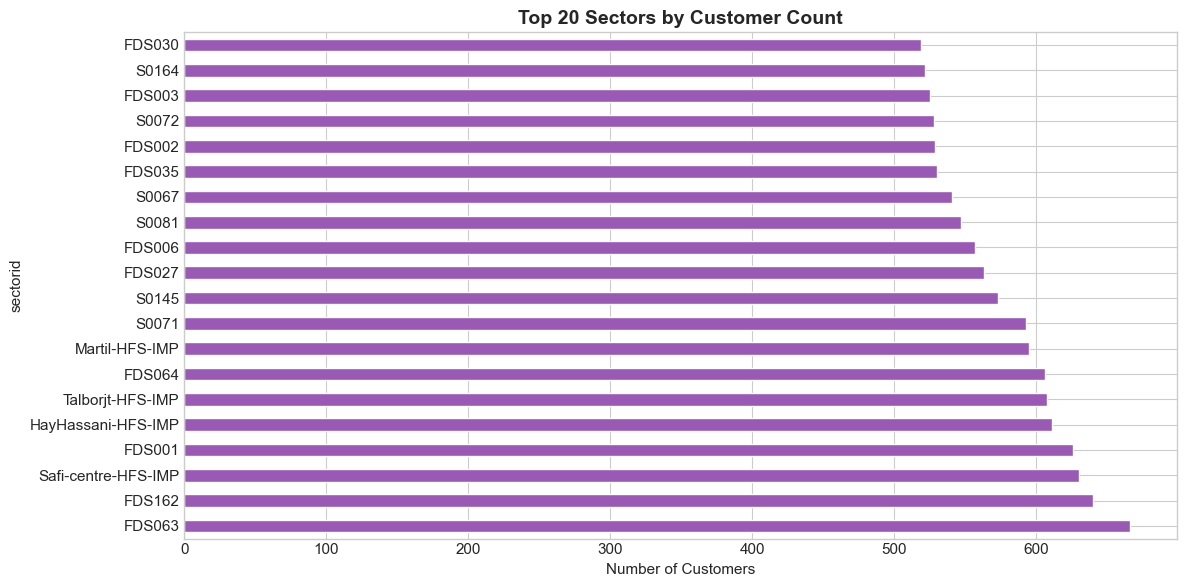

In [10]:
# ── Customers per sector (top 20) ──
fig, ax = plt.subplots(figsize=(12, 6))
sector_counts = customer['sectorid'].value_counts().head(20)
sector_counts.plot.barh(ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Top 20 Sectors by Customer Count')
ax.set_xlabel('Number of Customers')
plt.tight_layout()
plt.show()

### 3.4 Seller

In [11]:
seller = pd.read_csv(DATA_DIR / 'Seller.csv', sep=SEP, encoding='utf-8')
profile_dataframe('Seller', seller)


### 3.5 Product

In [12]:
product = pd.read_csv(DATA_DIR / 'Products.csv', sep=SEP, encoding='utf-8')
profile_dataframe('Product', product)


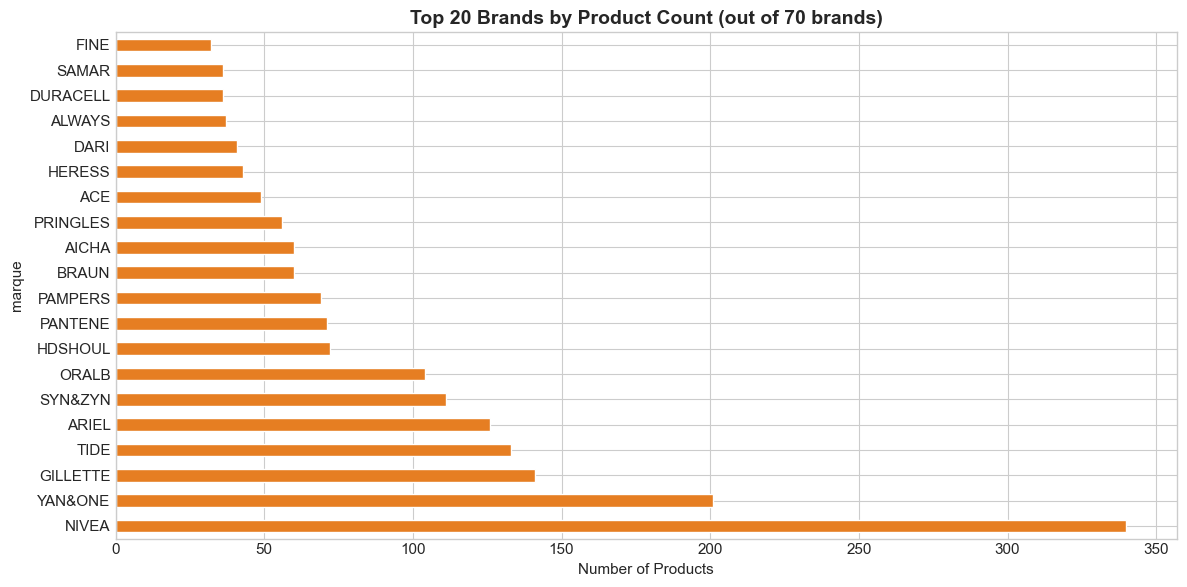

In [13]:
# ── Products per brand (top 20) ──
fig, ax = plt.subplots(figsize=(12, 6))
brand_counts = product['marque'].value_counts().head(20)
brand_counts.plot.barh(ax=ax, color='#e67e22', edgecolor='white')
ax.set_title(f'Top 20 Brands by Product Count (out of {product["marque"].nunique()} brands)')
ax.set_xlabel('Number of Products')
plt.tight_layout()
plt.show()

<a id='4'></a>
## 4. Fact Tables

> ⚠️ These tables are large. We load them with optimizations (chunk reading, specific columns only).

---

### 4.1 SalesHeader (~1.45M rows)

In [14]:
# ── Load SalesHeader ──
sales_header = pd.read_csv(DATA_DIR / 'SalesHeader.csv', sep=SEP, encoding='utf-8', low_memory=False)
sales_header['orderdate'] = pd.to_datetime(sales_header['orderdate'], errors='coerce')
sales_header['delivdate'] = pd.to_datetime(sales_header['delivdate'], errors='coerce')

profile_fact_table(
    'SalesHeader', sales_header,
    distinct_checks={
        'saleid':    'Distinct SaleID',
        'accountid': 'Distinct Customers',
        'sellerid':  'Distinct Sellers',
    }
)


In [15]:
# Statistical summary for amount columns
profile_dataframe(
    'SalesHeader — Amount Summary',
    sales_header[['bruteamount', 'netamount', 'taxamount', 'totalamount']].describe().round(2).reset_index().rename(columns={'index': 'stat'})
)


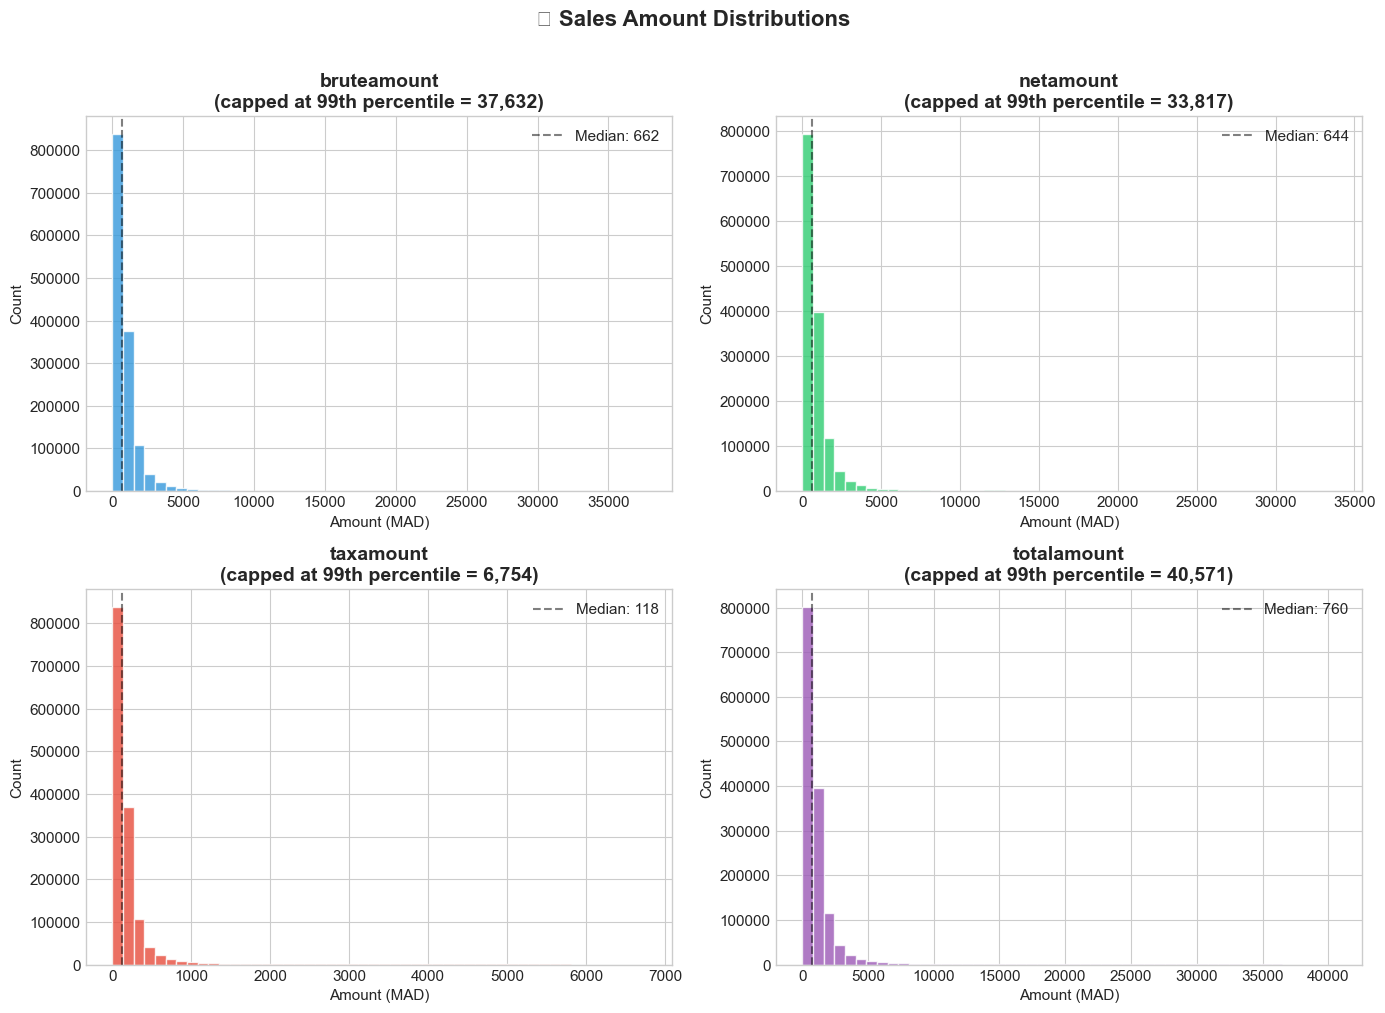

In [16]:
# ── Visual: Amount distributions ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

amount_cols = ['bruteamount', 'netamount', 'taxamount', 'totalamount']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, col, color in zip(axes.flat, amount_cols, colors):
    # Filter out extreme outliers for better visualization
    data = sales_header[col]
    q99 = data.quantile(0.99)
    filtered = data[data <= q99]
    
    ax.hist(filtered, bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'{col}\n(capped at 99th percentile = {q99:,.0f})')
    ax.set_xlabel('Amount (MAD)')
    ax.set_ylabel('Count')
    ax.axvline(data.median(), color='black', linestyle='--', alpha=0.5, label=f'Median: {data.median():,.0f}')
    ax.legend()

plt.suptitle('💰 Sales Amount Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# ── Date analysis ──
print(f'📅 Order date range: {sales_header["orderdate"].min()} → {sales_header["orderdate"].max()}')
print(f'📅 Delivery date range: {sales_header["delivdate"].min()} → {sales_header["delivdate"].max()}')

# Invalid dates
invalid_orders = sales_header['orderdate'].isnull().sum()
invalid_deliv = sales_header['delivdate'].isnull().sum()
print(f'\n⚠️  Invalid order dates: {invalid_orders}')
print(f'⚠️  Invalid delivery dates: {invalid_deliv}')

# Delivery before order?
late = (sales_header['delivdate'] < sales_header['orderdate']).sum()
print(f'⚠️  Delivery before order: {late} rows')

📅 Order date range: 2024-01-01 00:00:00 → 2024-12-31 00:00:00
📅 Delivery date range: 2024-01-02 00:00:00 → 2025-01-22 00:00:00

⚠️  Invalid order dates: 2
⚠️  Invalid delivery dates: 2
⚠️  Delivery before order: 6 rows


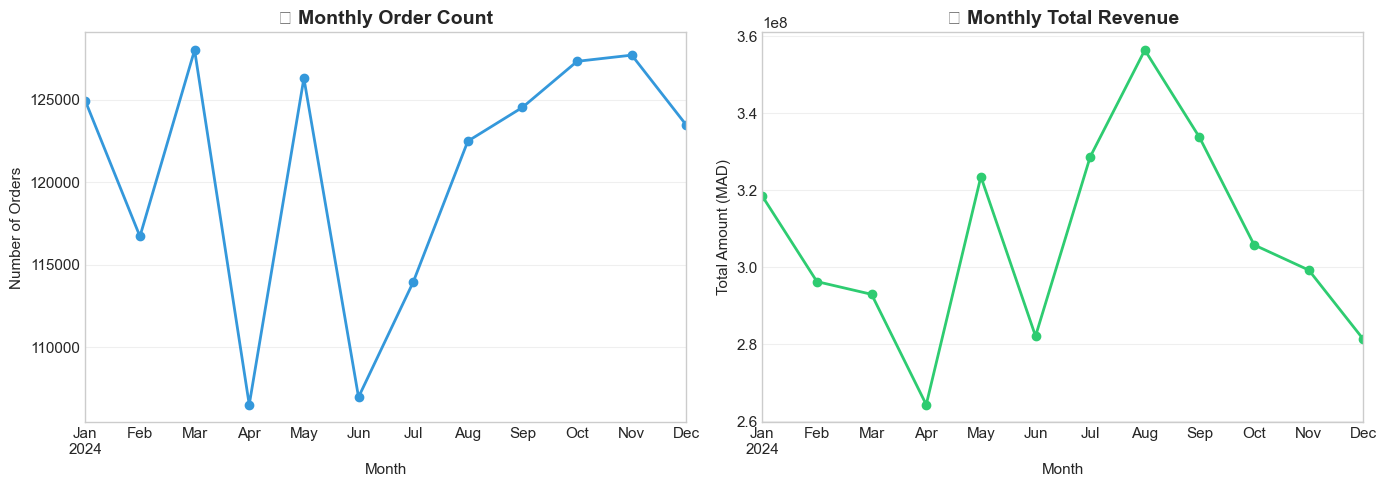

In [18]:
import matplotlib.pyplot as plt
# ── Visual: Orders over time ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly order count (use month-end frequency 'ME' as required by current pandas)
monthly_orders = sales_header.set_index('orderdate').resample('ME').size()
monthly_orders.plot(ax=axes[0], color='#3498db', linewidth=2, marker='o')
axes[0].set_title('📈 Monthly Order Count')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Orders')
axes[0].grid(True, alpha=0.3)

# Monthly revenue (use month-end frequency 'ME' as required by current pandas)
monthly_revenue = sales_header.set_index('orderdate').resample('ME')['totalamount'].sum()
monthly_revenue.plot(ax=axes[1], color='#2ecc71', linewidth=2, marker='o')
axes[1].set_title('💰 Monthly Total Revenue')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Amount (MAD)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

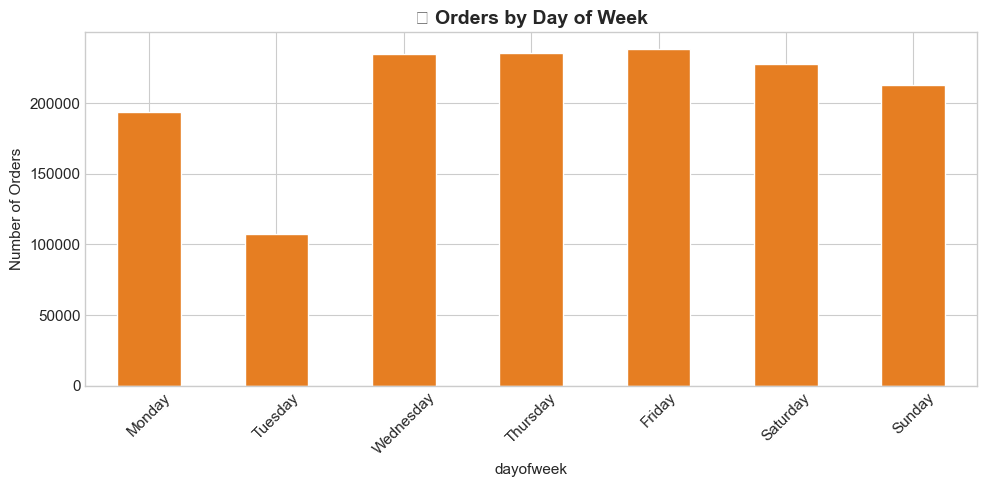

In [19]:
# ── Daily pattern: which days of the week get most orders? ──
fig, ax = plt.subplots(figsize=(10, 5))

sales_header['dayofweek'] = sales_header['orderdate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = sales_header['dayofweek'].value_counts().reindex(day_order)

day_counts.plot.bar(ax=ax, color='#e67e22', edgecolor='white')
ax.set_title('📅 Orders by Day of Week')
ax.set_ylabel('Number of Orders')
ax.set_xticklabels(day_order, rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Top 15 sellers by revenue
top_sellers = sales_header.groupby('sellerid', as_index=False).agg(
    num_orders=('saleid', 'count'),
    total_revenue=('totalamount', 'sum'),
    avg_order_value=('totalamount', 'mean')
).sort_values('total_revenue', ascending=False).head(15)

top_sellers = top_sellers.merge(
    seller.rename(columns={'sellerid': 'sellerid_str'}),
    left_on=top_sellers['sellerid'].astype(str),
    right_on='sellerid_str',
    how='left'
)

profile_dataframe(
    'Top 15 Sellers by Revenue',
    top_sellers[['sellerid', 'sellername', 'num_orders', 'total_revenue', 'avg_order_value']].round(2).reset_index(drop=True)
)


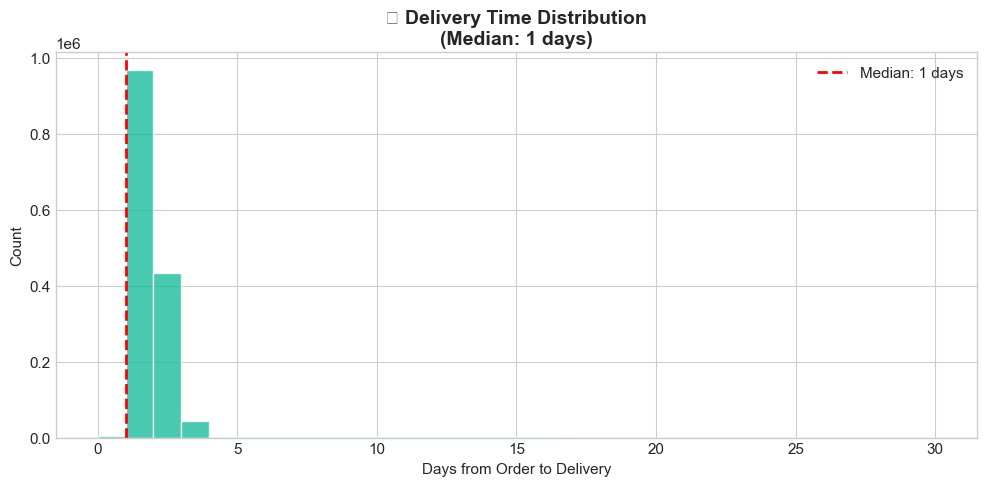

In [21]:
# ── Delivery time analysis ──
sales_header['delivery_days'] = (sales_header['delivdate'] - sales_header['orderdate']).dt.days

fig, ax = plt.subplots(figsize=(10, 5))
valid_delivery = sales_header['delivery_days'].dropna()
valid_delivery = valid_delivery[(valid_delivery >= 0) & (valid_delivery <= 30)]  # Filter reasonable values
ax.hist(valid_delivery, bins=range(0, 31), color='#1abc9c', edgecolor='white', alpha=0.8)
ax.set_title(f'🚚 Delivery Time Distribution\n(Median: {valid_delivery.median():.0f} days)')
ax.set_xlabel('Days from Order to Delivery')
ax.set_ylabel('Count')
ax.axvline(valid_delivery.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {valid_delivery.median():.0f} days')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 SalesLine (~10.6M rows)

> ⚠️ This file is **686 MB**. We load a sample of 500K rows for exploration, then count total rows.

In [22]:
# ── Load SalesLine sample ──
sales_line = pd.read_csv(DATA_DIR / 'SalesLine.csv', sep=SEP, encoding='cp1252',
                         nrows=500_000, low_memory=False)

import subprocess
result = subprocess.run(['powershell', '-Command',
    f'(Get-Content \"{DATA_DIR / "SalesLine.csv"}\" | Measure-Object -Line).Lines'],
    capture_output=True, text=True, timeout=120)
total_lines = int(result.stdout.strip()) - 1

profile_fact_table(
    f'SalesLine (sample 500K of {total_lines:,} total rows)', sales_line,
    distinct_checks={
        'saleid':   'Distinct SaleID',
        'itemid':   'Distinct Products',
        'promotype': 'Distinct Promo Types',
    }
)


In [23]:
# Statistical summary for SalesLine numeric columns
profile_dataframe(
    'SalesLine — Numeric Summary (sample 500K)',
    sales_line[['qty', 'unitprice', 'httotalamount', 'ttctotalamount', 'promovalue']].describe().round(2).reset_index().rename(columns={'index': 'stat'})
)


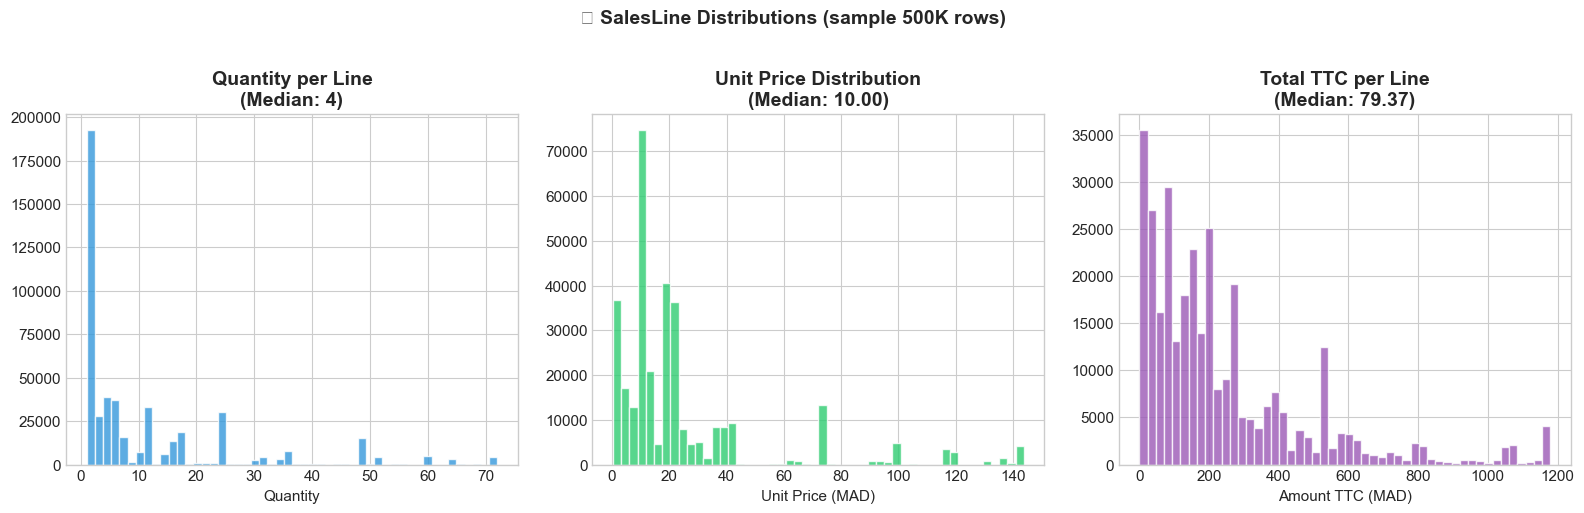

In [24]:
# ── Visual: Quantity and price distributions ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Quantity (filter outliers)
qty_data = sales_line['qty'][sales_line['qty'] <= sales_line['qty'].quantile(0.95)]
axes[0].hist(qty_data, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Quantity per Line\n(Median: {sales_line["qty"].median():.0f})')
axes[0].set_xlabel('Quantity')

# Unit price
price_data = sales_line['unitprice'][sales_line['unitprice'] > 0]
price_data = price_data[price_data <= price_data.quantile(0.95)]
axes[1].hist(price_data, bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Unit Price Distribution\n(Median: {sales_line["unitprice"].median():.2f})')
axes[1].set_xlabel('Unit Price (MAD)')

# Total amount per line
ttc_data = sales_line['ttctotalamount'][sales_line['ttctotalamount'] > 0]
ttc_data = ttc_data[ttc_data <= ttc_data.quantile(0.95)]
axes[2].hist(ttc_data, bins=50, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[2].set_title(f'Total TTC per Line\n(Median: {sales_line["ttctotalamount"].median():.2f})')
axes[2].set_xlabel('Amount TTC (MAD)')

plt.suptitle('📊 SalesLine Distributions (sample 500K rows)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

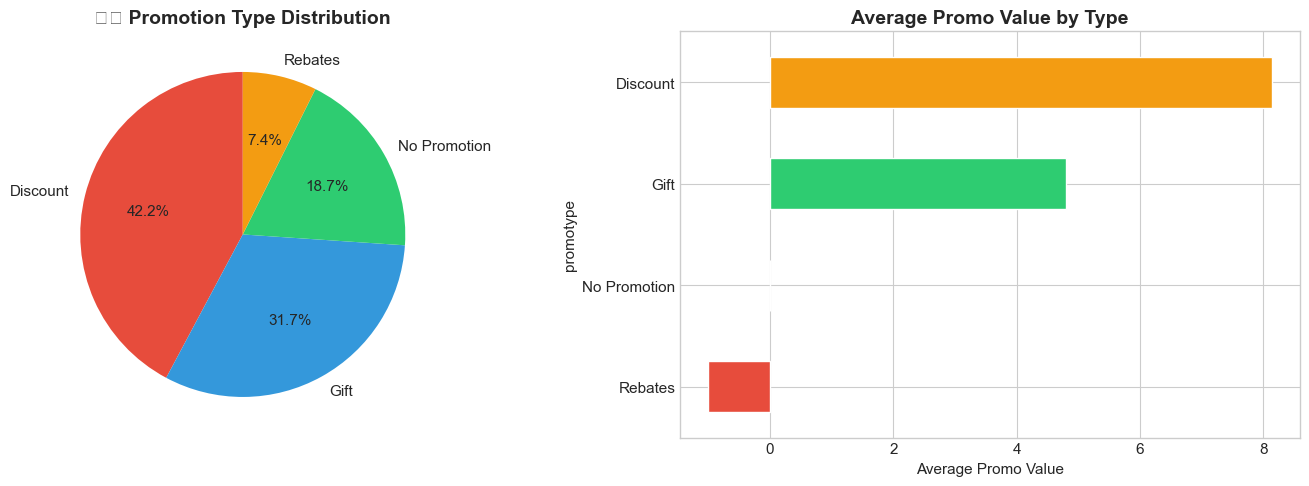


📊 Promotion breakdown:
  Discount            :  210,959 (42.2%)  |  Avg promo value: 8.14
  Gift                :  158,719 (31.7%)  |  Avg promo value: 4.81
  No Promotion        :   93,436 (18.7%)  |  Avg promo value: 0.00
  Rebates             :   36,886 (7.4%)  |  Avg promo value: -1.00


In [25]:
# ── Promotion types ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

promo_counts = sales_line['promotype'].value_counts()
colors_promo = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Pie chart
promo_counts.plot.pie(ax=axes[0], autopct='%1.1f%%', colors=colors_promo, startangle=90,
                       textprops={'fontsize': 11})
axes[0].set_title('🏷️ Promotion Type Distribution')
axes[0].set_ylabel('')

# Average promo value by type
promo_avg = sales_line.groupby('promotype')['promovalue'].mean().sort_values(ascending=True)
promo_avg.plot.barh(ax=axes[1], color=colors_promo[:len(promo_avg)], edgecolor='white')
axes[1].set_title('Average Promo Value by Type')
axes[1].set_xlabel('Average Promo Value')

plt.tight_layout()
plt.show()

print('\n📊 Promotion breakdown:')
for ptype, count in promo_counts.items():
    pct = count / len(sales_line) * 100
    avg_val = sales_line[sales_line['promotype'] == ptype]['promovalue'].mean()
    print(f'  {ptype:20s}: {count:>8,} ({pct:.1f}%)  |  Avg promo value: {avg_val:.2f}')

In [26]:
# Zero-price items (Gifts)
zero_price = sales_line[sales_line['unitprice'] == 0]
promo_breakdown = zero_price['promotype'].value_counts().reset_index()
promo_breakdown.columns = ['Promo Type', 'Count']
promo_breakdown.insert(0, 'Note', f'{len(zero_price):,} rows ({len(zero_price)/len(sales_line)*100:.1f}%) have unit price = 0')

profile_dataframe('Zero-Price Items — Promo Type Breakdown', promo_breakdown)


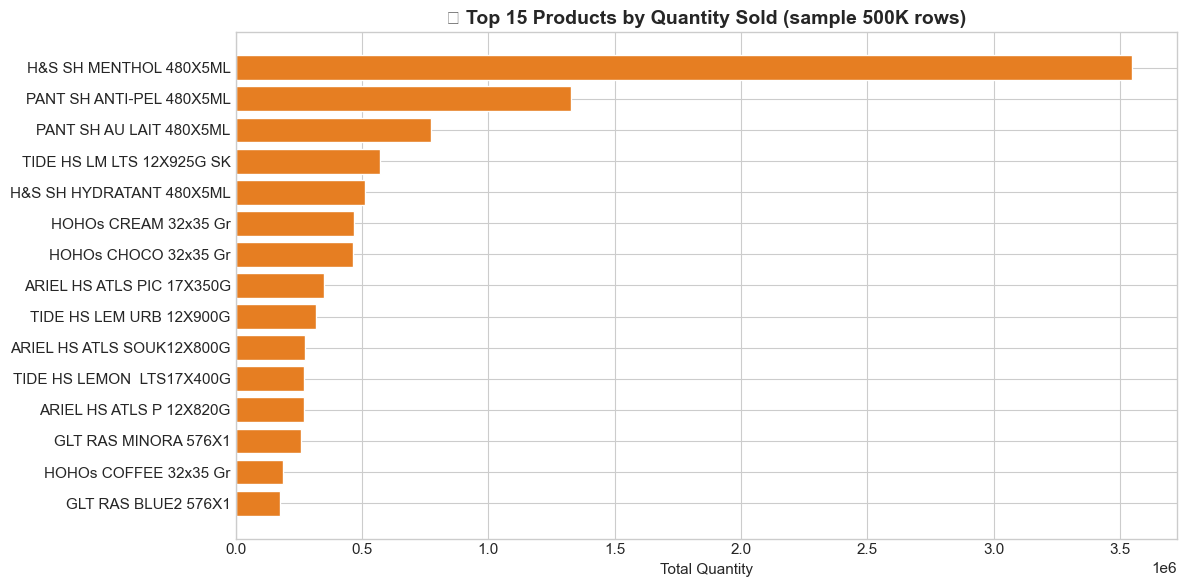

In [27]:
# ── Top products by quantity sold ──
top_products = sales_line.groupby('itemid')['qty'].sum().sort_values(ascending=False).head(15)
top_products_df = top_products.reset_index().merge(product, on='itemid', how='left')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_products_df)), top_products_df['qty'], color='#e67e22', edgecolor='white')
ax.set_yticks(range(len(top_products_df)))
ax.set_yticklabels([f"{n[:30]}" for n in top_products_df['name'].fillna('Unknown')])
ax.set_title('🏆 Top 15 Products by Quantity Sold (sample 500K rows)')
ax.set_xlabel('Total Quantity')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3 Invoice (~1.45M rows)

In [28]:
# ── Load Invoice ──
invoice = pd.read_csv(DATA_DIR / 'Invoice.csv', sep=SEP, encoding='cp1252',
                      decimal=',', low_memory=False)

profile_fact_table(
    'Invoice', invoice,
    distinct_checks={
        'invoiceid':     'Distinct InvoiceID',
        'salesid':       'Distinct SaleID',
        'paymentmethod': 'Distinct Payment Methods',
    }
)


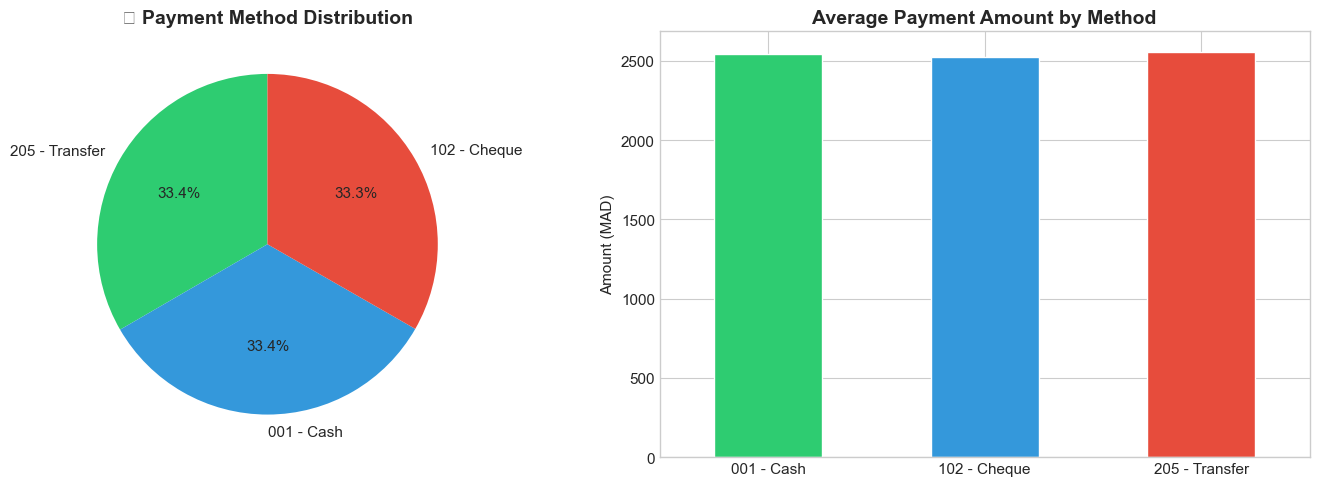


📊 Payment method breakdown:
  205 - Transfer      :    483,398 (33.4%)  |  Avg amount: 2,558.58 MAD
  001 - Cash          :    483,394 (33.4%)  |  Avg amount: 2,540.47 MAD
  102 - Cheque        :    482,188 (33.3%)  |  Avg amount: 2,526.32 MAD


In [29]:
# ── Payment methods ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pm_counts = invoice['paymentmethod'].value_counts()
pm_labels = {1: '001 - Cash', 102: '102 - Cheque', 205: '205 - Transfer'}
pm_names = [pm_labels.get(m, str(m)) for m in pm_counts.index]

# Count by method
colors_pm = ['#2ecc71', '#3498db', '#e74c3c']
axes[0].pie(pm_counts, labels=pm_names, autopct='%1.1f%%', colors=colors_pm, startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('💳 Payment Method Distribution')

# Average amount by method
pm_avg = invoice.groupby('paymentmethod')['paymentamount'].mean()
pm_avg.index = [pm_labels.get(m, str(m)) for m in pm_avg.index]
pm_avg.plot.bar(ax=axes[1], color=colors_pm, edgecolor='white')
axes[1].set_title('Average Payment Amount by Method')
axes[1].set_ylabel('Amount (MAD)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print('\n📊 Payment method breakdown:')
for method, count in pm_counts.items():
    pct = count / len(invoice) * 100
    avg = invoice[invoice['paymentmethod'] == method]['paymentamount'].mean()
    label = pm_labels.get(method, str(method))
    print(f'  {label:20s}: {count:>10,} ({pct:.1f}%)  |  Avg amount: {avg:,.2f} MAD')

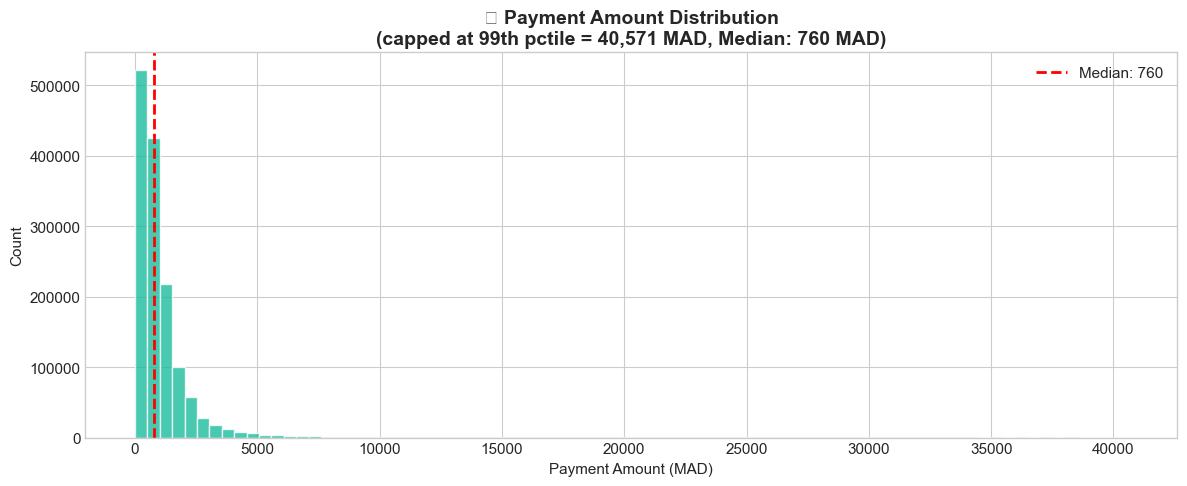

In [30]:
# ── Payment amount distribution ──
fig, ax = plt.subplots(figsize=(12, 5))

pay_data = invoice['paymentamount']
q99 = pay_data.quantile(0.99)
filtered = pay_data[pay_data <= q99]

ax.hist(filtered, bins=80, color='#1abc9c', edgecolor='white', alpha=0.8)
ax.set_title(f'💰 Payment Amount Distribution\n(capped at 99th pctile = {q99:,.0f} MAD, Median: {pay_data.median():,.0f} MAD)')
ax.set_xlabel('Payment Amount (MAD)')
ax.set_ylabel('Count')
ax.axvline(pay_data.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {pay_data.median():,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

<a id='5'></a>
## 5. Missing Values Summary

A global view of data quality across all tables:

In [31]:
# ── Global missing values summary ──
all_tables = {
    'Region':               region,
    'Sector':               sector,
    'Customer':             customer,
    'Seller':               seller,
    'Product':              product,
    'SalesHeader':          sales_header,
    'SalesLine (500K)':     sales_line,
    'Invoice':              invoice,
}

missing_summary = []
for table_name, df in all_tables.items():
    for col in df.columns:
        miss_count = df[col].isnull().sum()
        miss_pct   = miss_count / len(df) * 100
        missing_summary.append({
            'Table':      table_name,
            'Column':     col,
            'Missing':    miss_count,
            'Missing %':  round(miss_pct, 2),
            'Total Rows': len(df)
        })

missing_all    = pd.DataFrame(missing_summary)
missing_issues = missing_all[missing_all['Missing'] > 0].reset_index(drop=True)

profile_dataframe('Missing Values — All Tables (only columns with nulls)', missing_issues)


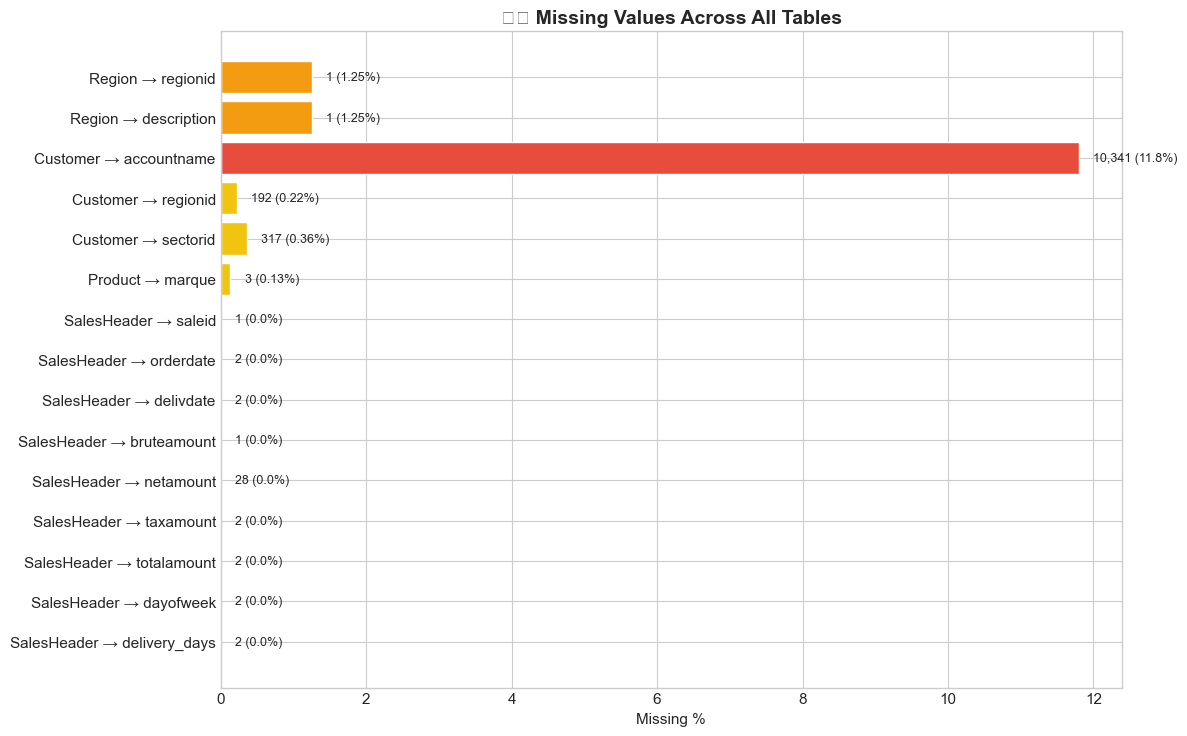

In [32]:
# ── Visual: Missing values chart ──
if len(missing_issues) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(missing_issues) * 0.5)))
    
    labels = missing_issues['Table'] + ' → ' + missing_issues['Column']
    colors_miss = ['#e74c3c' if p > 5 else '#f39c12' if p > 1 else '#f1c40f' 
                   for p in missing_issues['Missing %']]
    
    ax.barh(range(len(labels)), missing_issues['Missing %'], color=colors_miss, edgecolor='white')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel('Missing %')
    ax.set_title('⚠️ Missing Values Across All Tables')
    ax.invert_yaxis()
    
    # Add count labels
    for i, (pct, count) in enumerate(zip(missing_issues['Missing %'], missing_issues['Missing'])):
        ax.text(pct + 0.2, i, f'{count:,} ({pct}%)', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

<a id='6'></a>
## 6. Referential Integrity

Check that foreign keys in fact tables point to valid dimension records:

In [33]:
# ── Customer → Region ──
orphan_regions = set(customer['regionid'].dropna()) - set(region['regionid'].dropna())
if orphan_regions:
    print(f'⚠️  Customer has {len(orphan_regions)} regionid values NOT in Region table:')
    print(f'   Examples: {list(orphan_regions)[:10]}')
else:
    print('✅ Customer → Region: All regionid values are valid')

# ── Customer → Sector ──
orphan_sectors = set(customer['sectorid'].dropna()) - set(sector['sectorid'].dropna())
if orphan_sectors:
    print(f'⚠️  Customer has {len(orphan_sectors)} sectorid values NOT in Sector table:')
    print(f'   Examples: {list(orphan_sectors)[:10]}')
else:
    print('✅ Customer → Sector: All sectorid values are valid')

⚠️  Customer has 15 regionid values NOT in Region table:
   Examples: ['Marrakech', 'HayHassani-HFS-IMP', 'Meknes', 'Tanger', 'OUJDA', 'Rabat - Salé', 'Essalam-HFS-IMP', 'Agdal-HFS-IMP', 'Tetouan', 'Daraa-Tafilalt']
⚠️  Customer has 1 sectorid values NOT in Sector table:
   Examples: ['K?nitra-Ville-IMP']


In [34]:
# ── SalesHeader → Customer ──
customer_ids = set(customer['accountid'].astype(str))
header_customers = set(sales_header['accountid'].astype(str).str.strip())
orphan_customers = header_customers - customer_ids

if orphan_customers:
    print(f'⚠️  SalesHeader has {len(orphan_customers)} accountid values NOT in Customer table:')
    print(f'   Examples: {list(orphan_customers)[:10]}')
else:
    print('✅ SalesHeader → Customer: All accountid values are valid')

# ── SalesHeader → Seller ──
seller_ids = set(seller['sellerid'].astype(str))
header_sellers = set(sales_header['sellerid'].astype(str))
orphan_sellers = header_sellers - seller_ids

if orphan_sellers:
    print(f'⚠️  SalesHeader has {len(orphan_sellers)} sellerid values NOT in Seller table:')
    print(f'   Examples: {list(orphan_sellers)[:10]}')
else:
    print('✅ SalesHeader → Seller: All sellerid values are valid')

⚠️  SalesHeader has 17141 accountid values NOT in Customer table:
   Examples: ['CF000580', 'CF004755', 'CLT-C00001', 'C02776', 'CC008159', 'FDER01049', 'CJ5000164', 'CF02086', 'CF000937', 'FDPERF00253']
⚠️  SalesHeader has 83 sellerid values NOT in Seller table:
   Examples: ['1227', '2027', '1234', '214', '2204', '239', '515', '2024', '550', '251']


In [35]:
# ── SalesLine → Product (sample) ──
product_ids = set(product['itemid'].astype(str))
line_products = set(sales_line['itemid'].astype(str))
orphan_products = line_products - product_ids

if orphan_products:
    print(f'⚠️  SalesLine has {len(orphan_products)} itemid values NOT in Product table (sample 500K):')
    print(f'   Examples: {list(orphan_products)[:10]}')
else:
    print('✅ SalesLine → Product: All itemid values are valid (sample)')

# ── Invoice → SalesHeader ──
header_sales = set(sales_header['saleid'].astype(str))
invoice_sales = set(invoice['salesid'].astype(str))
orphan_invoices = invoice_sales - header_sales

if orphan_invoices:
    print(f'⚠️  Invoice has {len(orphan_invoices)} salesid values NOT in SalesHeader:')
    print(f'   Examples: {list(orphan_invoices)[:10]}')
else:
    print('✅ Invoice → SalesHeader: All salesid values are valid')

✅ SalesLine → Product: All itemid values are valid (sample)
✅ Invoice → SalesHeader: All salesid values are valid


<a id='7'></a>
## 7. Key Findings & Next Steps

### ✅ What's Good
- **13.5 million total rows** — solid dataset for ML models
- **Full year 2024** of data (Jan → Dec)
- **No negative amounts** in any financial column
- **Clean primary keys** — no missing IDs in fact tables
- **4 promotion types** — useful for Subject 5 analysis
- **3 payment methods** — enough for payment analysis

### ⚠️ Issues to Fix in ETL
1. **Sector.csv** must be read with `cp1252` encoding
2. **11.8% of customer names** are missing (10,341 rows)
3. **Whitespace** in accountnames, sellernames, and some accountids
4. **5 duplicate customers** and **~1,900 duplicate SalesLine rows**
5. **Invoice.csv** uses comma as decimal separator
6. **saleid** type inconsistency (int64 vs object across files)
7. **1 delivery** dated before its order date

### 📋 Next Steps
- Build the ETL pipeline to clean and load data into SQL Server
- Handle missing customer names (keep as "Unknown" or drop?)
- Standardize saleid type across all tables
- Move on to EDA (notebook 02)

In [36]:
print('\n🎉 Data Profiling Complete!')
print('\n📊 Summary:')
print(f'  Region:        {len(region):>10,} rows')
print(f'  Sector:        {len(sector):>10,} rows')
print(f'  Customer:      {len(customer):>10,} rows')
print(f'  Seller:        {len(seller):>10,} rows')
print(f'  Product:       {len(product):>10,} rows')
print(f'  SalesHeader:   {len(sales_header):>10,} rows')
print(f'  SalesLine:     {total_lines:>10,} rows (estimated)')
print(f'  Invoice:       {len(invoice):>10,} rows')
total = len(region) + len(sector) + len(customer) + len(seller) + len(product) + len(sales_header) + total_lines + len(invoice)
print(f'  {"─"*35}')
print(f'  TOTAL:         {total:>10,} rows')


🎉 Data Profiling Complete!

📊 Summary:
  Region:                80 rows
  Sector:               331 rows
  Customer:          87,668 rows
  Seller:               409 rows
  Product:            2,319 rows
  SalesHeader:    1,448,981 rows
  SalesLine:     10,577,126 rows (estimated)
  Invoice:        1,448,980 rows
  ───────────────────────────────────
  TOTAL:         13,565,894 rows
